# 决策树训练和可视化


---

## 1. 决策树的训练 (Training)

决策树的训练过程本质上是**递归分裂**的过程。模型会不断寻找一个特征及其阈值，将数据集分成两部分，直到满足停止条件。

* **数据准备**：决策树不需要对特征进行缩放（Scaling）或中心化（Centering），这是它的一大优势。
* **训练代码**：使用 `DecisionTreeClassifier` 类，通过 `max_depth` 等参数控制树的生长。
* **CART 算法**：Scikit-Learn 使用 CART（Classification and Regression Tree）算法来训练决策树。它采用二元切分，即每次分裂只产生两个子节点。

---

## 2. 决策树的可视化 (Visualization)

决策树是典型的**白盒模型**，其决策逻辑可以通过图表直观展示。



### 如何阅读可视化图表？

一个典型的决策树节点包含以下信息：

1. **判定条件**：例如 `petal width (cm) <= 0.8`。如果不满足，则走向右子节点。
2. **Gini (基尼系数)**：衡量节点的不纯度。`Gini = 0` 表示该节点内所有样本属于同一类。
3. **Samples**：该节点处理的样本总数。
4. **Value**：每个类别在节点中的样本分布。
5. **Class**：该节点最终预测的类别。

---

## 3. 决策边界 (Decision Boundaries)

当我们将决策树的判定过程画在坐标系中，会发现它的边界是由**垂直于坐标轴的直线**组成的。

* **分层特性**：树每增加一层，就会在平面上切一刀。
* **局部优化**：决策树在每一层都寻找当前最优的切分点（贪心算法），而不考虑全局是否最优。

---

### 核心要点总结

| 维度 | 内容说明 |
| --- | --- |
| **解释性** | 极高（白盒模型），可以清晰追踪每一条预测路径 |
| **数据处理** | 无需特征缩放，对异常值具有一定的鲁棒性 |
| **限制** | 只能生成垂直于轴的边界，可能对旋转敏感 |


In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
iris = load_iris()
X = iris.data[:,2:]
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2)
tree_clf.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


可视化：

In [2]:
from sklearn.tree import export_graphviz
export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    rounded=True,
    filled=True)

# 做出预测


---

## 1. 预测流程：从根到叶

当有一个新样本（比如一朵新的鸢尾花）需要分类时，预测过程如下：

* **路径追踪**：从根节点开始，根据样本的特征值（如 `petal width`）回答“是”或“否”。
* **节点流转**：
* 如果回答为“是”（True），则移动到左子节点。
* 如果回答为“否”（False），则移动到右子节点。


* **最终判定**：重复上述过程，直到到达一个**叶节点**（没有子节点的节点）。该叶节点所属的 `class` 就是最终的预测类别。

---

## 2. 估计类别概率 (Estimating Class Probabilities)

决策树不仅能给出一个明确的类别，还能给出该样本属于某个类别的**概率**。

* **计算逻辑**：模型会找到该样本所属的叶节点，并计算该节点中属于某个类别的样本比例。

---

## 3. 预测的时间复杂度

决策树的预测效率极高，这也是它广受欢迎的原因之一：

* **搜索深度**：预测需要遍历的节点数量大约为 $\log_2(m)$，其中 $m$ 是训练样本数。
* **性能**：即便训练集非常大，预测速度依然飞快，因为处理每个样本只需要检查极少量的特征。

---

###  总结

| 功能 | 核心逻辑 |
| --- | --- |
| **预测类别** | 沿路径走到叶节点，取该节点中样本最多的类 |
| **预测概率** | 计算目标叶节点中各类别样本所占的比例 |
| **优势** | 逻辑清晰（白盒），预测速度极快 ($O(\log m)$) |


**基尼不纯度（Gini Impurity）**。它是决策树选择如何“砍下一刀”的关键依据。

---

### 1. 什么是基尼不纯度？

基尼不纯度衡量的是一个节点的“混乱程度”。

* **纯净状态**：如果一个节点只包含一种类别的样本，该节点就是“纯”的，基尼不纯度等于 **0**。
* **混乱状态**：如果各类别样本分布均匀，基尼不纯度就会很高（最大值为 $0.5$，针对二分类问题）。

---

### 2. 数学公式

第 $i$ 个节点的基尼不纯度 $G_i$ 计算公式如下：

$$G_i = 1 - \sum_{k=1}^{n} p_{i,k}^2$$

* **$p_{i,k}$**：是第 $i$ 个节点中，属于第 $k$ 类的样本占该节点总样本数的比例。

---

### 3. 实例演算 (结合 `iris_tree.png`)

让我们用生成的图表数据来手动算一遍，加深理解：

#### 案例 A：根节点（最上方白色方框）

* **样本分布**：`value = [50, 50, 50]`，总计 150 个样本。
* **计算**：
* $p_{Setosa} = 50/150 = 1/3$
* $p_{Versicolor} = 50/150 = 1/3$
* $p_{Virginica} = 50/150 = 1/3$
* $Gini = 1 - ( (1/3)^2 + (1/3)^2 + (1/3)^2 ) = 1 - 3/9 = 2/3 \approx \mathbf{0.667}$

#### 案例 B：左侧叶节点（橙色方框）

* **样本分布**：`value = [50, 0, 0]`，总计 50 个样本。
* **计算**：
* $Gini = 1 - ( (50/50)^2 + 0^2 + 0^2 ) = 1 - 1 = \mathbf{0.0}$


* **结论**：这是一个完美的纯净节点。

#### 案例 C：底部左侧叶节点（绿色方框）

* **样本分布**：`value = [0, 49, 5]`，总计 54 个样本。
* **计算**：
* $Gini = 1 - ( (0/54)^2 + (49/54)^2 + (5/54)^2 ) \approx 1 - (0.823 + 0.0086) \approx \mathbf{0.168}$

---

### 笔记

| 特性 | 说明 |
| --- | --- |
| **物理含义** | 节点中随机选中一个样本并根据分布预测其类别，预测错误的概率 |
| **最优值** | **0**（代表节点完全纯净） |
| **训练目标** | 在每次分裂时，最大程度地降低子节点的加权基尼不纯度 |

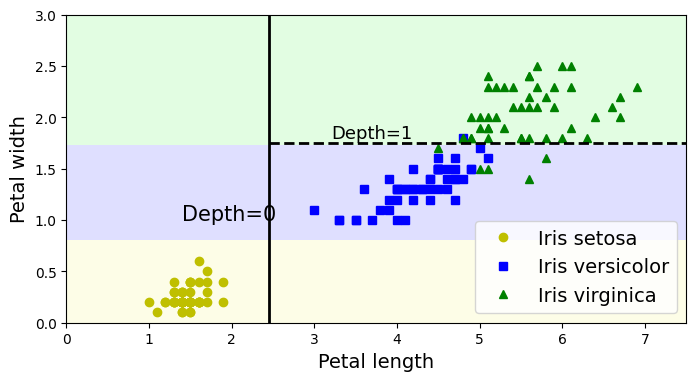

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes=[0, 7.5, 0, 3], iris=True, plot_training=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    # 设置背景颜色
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)

    if not iris:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)

    if plot_training:
        plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
        plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
        plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris virginica")
        plt.axis(axes)

    if iris:
        plt.xlabel("Petal length", fontsize=14)
        plt.ylabel("Petal width", fontsize=14)
    else:
        plt.xlabel(r"$x_1$", fontsize=18)
        plt.ylabel(r"$x_2$", fontsize=18, rotation=0)
    plt.legend(loc="lower right", fontsize=14)

# 执行绘图
plt.figure(figsize=(8, 4))
plot_decision_boundary(tree_clf, X, y)

# 绘制决策树的分割线（手动根据树结构添加，对应深度 0 和 深度 1）
plt.plot([2.45, 2.45], [0, 3], "k-", linewidth=2)      # 深度 0 的分割线
plt.plot([2.45, 7.5], [1.75, 1.75], "k--", linewidth=2) # 深度 1 的分割线
plt.text(1.40, 1.0, "Depth=0", fontsize=15)
plt.text(3.2, 1.80, "Depth=1", fontsize=13)

plt.show()

---

### 图表深度解读


1. **第一刀（Depth=0）**：在花瓣长度为 **2.45 cm** 处垂直切开。左侧区域（黄色背景）全是山鸢尾（Setosa），这对应了在 `iris_tree.png` 中看到的左侧纯净叶节点。
2. **第二刀（Depth=1）**：由于右侧区域还是混合的，模型在花瓣宽度 **1.75 cm** 处水平切了一刀。
* **下方区域**：主要是变色鸢尾（Versicolor）。
* **上方区域**：主要是维吉尼亚鸢尾（Virginica）。


3. **正交性**：注意到所有的分割线不是水平就是垂直的，这是因为决策树每次只测试一个特征。这也意味着决策树对数据集的**旋转**非常敏感。

---

# CART算法


Scikit-Learn 选用的是 CART 算法，它通过一种**递归贪婪**的方式来寻找最优的切分方案。

---

### 1. 核心逻辑：寻找最优切分

CART 算法在训练时，会将特征空间不断地一分为二。在每一个节点，它会搜索所有的特征 $k$ 和该特征下所有的阈值 $t_k$，寻找能产生**最纯净**子集的组合。

---

### 2. 代价函数 (Cost Function)

算法通过最小化以下代价函数来选择最优的 $(k, t_k)$ 对：

$$J(k, t_k) = \frac{m_{left}}{m} G_{left} + \frac{m_{right}}{m} G_{right}$$

* **$m_{left}/m$**：左侧子节点的样本占比。
* **$G_{left}$**：左侧子节点的基尼不纯度。
* **含义**：它计算的是两个子节点不纯度的**加权平均值**。算法的目标是让这个总和达到最小。

---

### 3. 递归与停止条件

一旦成功将数据集切分为二，算法会对产生的子集重复执行相同的逻辑。这是一种**递归过程**。

为了防止树无限制地长下去（导致严重的过拟合），算法会在满足以下条件时停止：

* 达到预设的最大深度（`max_depth`）。
* 分裂已经无法进一步降低不纯度。
* 节点中的样本数少于设定的最小阈值（如 `min_samples_split`）。

---

### 4. 贪心算法的特性

CART 算法是一种**贪心算法（Greedy Algorithm）**。

* 它只考虑**当前这一步**的最优切分，并不检查通过几层分裂后是否能达到全局最优。
* 虽然贪心方案不一定能找到数学上的绝对最优树，但它能以合理的计算成本找到一个足够好的解。

---

### 总结笔记

| 特性 | CART 算法说明 |
| --- | --- |
| **结构** | 仅产生**二叉树**（每个节点只有两个分支） |
| **效率** | 训练复杂度通常为 $O(n \cdot m \log m)$，预测为 $O(\log m)$ |
| **目标** | 最小化子节点的加权基尼不纯度之和 |


## 计算复杂度

决策树预测的时间复杂度为 $\mathcal{O}(\text{depth})$。
对于平衡树，$\mathcal{O}(\log n)$；最坏情况下 $\mathcal{O}(n)$。

## 基尼不纯度还是信息熵

在决策树的训练中，**信息熵（Entropy）**是除基尼不纯度之外最常用的另一种衡量指标。它们的目的相同：衡量一个节点的“纯净度”或“混乱程度”。

---

### 1. 什么是信息熵 (Entropy)？

信息熵源于信息论，用于衡量系统的信息量或不确定性。

* **物理含义**：如果一个节点包含的所有样本都属于同一类，它的信息熵为 **0**（完全确定）。
* **混乱状态**：如果样本均匀分布在各个类别中，熵值达到最大（不确定性最高）。

#### 数学公式

第 $i$ 个节点的熵 $H_i$ 计算如下：


$$H_i = -\sum_{k=1, p_{i,k} \neq 0}^{n} p_{i,k} \log_2(p_{i,k})$$

---

### 2. 信息熵 vs. 基尼不纯度：对比

在 Scikit-Learn 的 `DecisionTreeClassifier` 中，可以通过 `criterion` 参数在两者之间切换。

| 特性 | 基尼不纯度 (Gini) | 信息熵 (Entropy) |
| --- | --- | --- |
| **默认设置** | 是，Scikit-Learn 的默认选项 | 需手动设置 `criterion="entropy"` |
| **计算复杂度** | **较低**。仅需进行平方运算，速度较快。 | **较高**。涉及对数（$\log$）计算，耗时相对略长。 |
| **树的形状** | 倾向于在节点中切出最常见的类别。 | 倾向于产生更加**平衡**的树结构。 |
| **实际表现** | 两者在大多数情况下生成的决策树非常相似。 | 在某些特定数据集上可能表现稍好，但差异通常不显著。 |

---

### 3. 如何选择？

* **首选基尼不纯度**：因为它计算速度更快，且在大多数任务中效果已经足够好。
* **尝试信息熵**：如果数据集较小，或者基尼不纯度生成的树看起来非常不平衡，可以切换到熵来看看模型性能是否有提升。

---

### 核心笔记总结

无论是 Gini 还是 Entropy，决策树训练的核心逻辑是不变的：**在每次分裂时，寻找能让子节点“总混乱度”降得最多的那个切分点**。


# 正则化超参数

决策树是一种**非参数模型**，这意味着在训练前它不对参数数量做限制，因此它非常容易“放飞自我”，紧紧贴合训练数据的每一个噪声点，从而导致严重的**过拟合**。

为了让这棵树长得更健康（提高泛化能力），我们需要通过**正则化超参数**来限制它的生长。

---

### 1. 核心超参数：限制生长

在 Scikit-Learn 的 `DecisionTreeClassifier` 中，可以通过以下参数进行“修剪”：

* **`max_depth` (最大深度)**：
* 这是最直观的限制。
* 减小它可以降低过拟合风险，让模型更简单。


* **`min_samples_split` (分裂所需最小样本数)**：
* 一个节点必须至少拥有这么多样本，才允许被进一步分裂。


* **`min_samples_leaf` (叶节点所需最小样本数)**：
* 任何一个叶节点（终端节点）都必须包含至少这么多样本。
* 设置较大的值可以防止模型为了个别异常值而产生孤立的细小分支。


* **`max_leaf_nodes` (最大叶节点数量)**：
* 限制整棵树中叶节点的最大个数。


* **`max_features` (分裂时考虑的最大特征数)**：
* 在每个节点评估分裂时，随机选择的特征数量上限。

---

### 2. 规律总结：如何调优？

* **增加**以 `min_` 开头的参数，或**减少**以 `max_` 开头的参数，都会使模型受到更多约束，从而**降低过拟合**。
* 反之，放宽这些限制会增强模型的拟合能力，但也可能引入更多噪声。

---

### 3. 剪枝 (Pruning) 策略

除了在生长过程中限制（预剪枝），还有一种策略是先让树长全，然后再剪掉不必要的枝叶（后剪枝）。

* **统计显著性检验**：如果一个分裂带来的纯度提升在统计上不显著（例如使用 $\chi^2$ 检验），则撤销该分裂。
* Scikit-Learn 主要采用的是**预剪枝**参数，简单且高效。

---

### 正则化对比笔记

| 状态 | 特征 | 调整建议 |
| --- | --- | --- |
| **过拟合 (Overfitting)** | 训练集表现完美，测试集很差 | 减小 `max_depth`，增加 `min_samples_leaf` |
| **欠拟合 (Underfitting)** | 训练集和测试集表现都很差 | 增加 `max_depth`，放宽 `min_` 系列限制 |


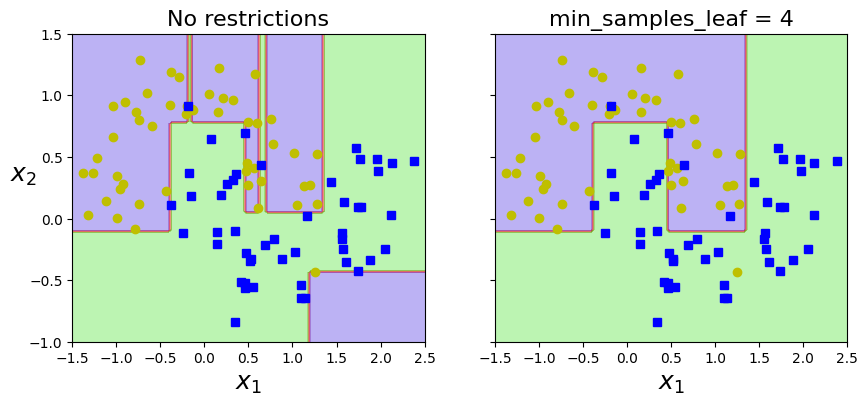

In [4]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt

# 1. 准备卫星数据集 (Moons Dataset)
Xm, ym = make_moons(n_samples=100, noise=0.25, random_state=53)

# 2. 训练两个模型：一个无约束，一个设置 min_samples_leaf=4
deep_tree_clf1 = DecisionTreeClassifier(random_state=42)
deep_tree_clf2 = DecisionTreeClassifier(min_samples_leaf=4, random_state=42)
deep_tree_clf1.fit(Xm, ym)
deep_tree_clf2.fit(Xm, ym)

# 3. 定义绘图函数
def plot_decision_boundary(clf, X, y, axes=[-1.5, 2.5, -1, 1.5]):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=plt.cm.brg)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)

# 4. 绘图对比
fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

# 左图：无约束
plt.sca(axes[0])
plot_decision_boundary(deep_tree_clf1, Xm, ym)
plt.title("No restrictions", fontsize=16)

# 右图：min_samples_leaf=4
plt.sca(axes[1])
plot_decision_boundary(deep_tree_clf2, Xm, ym)
plt.title("min_samples_leaf = 4", fontsize=16)
plt.ylabel("")

plt.show()

# 回归

决策树不仅能做分类，还能处理**回归（Regression）**任务。在回归模型中，它不再预测一个类别，而是预测一个**具体的数值**。

---

## 1. 回归的工作原理

决策树回归的逻辑与分类非常相似，但有两个核心区别：

* **预测值**：每个叶节点预测的不再是一个类别，而是该节点内所有训练样本**目标值的平均值**。
* **分裂标准**：CART 算法不再最小化基尼不纯度，而是最小化**均方误差（MSE）**。

---

## 2. 算法与代价函数

在回归任务中，CART 算法尝试通过最小化以下代价函数来拆分训练集：

$$J(k, t_k) = \frac{m_{left}}{m} MSE_{left} + \frac{m_{right}}{m} MSE_{right}$$

其中每个节点的 MSE 计算如下：

* $\hat{y}_{node} = \frac{1}{m_{node}} \sum_{i \in node} y^{(i)}$ （节点预测值）
* $MSE_{node} = \sum_{i \in node} (y^{(i)} - \hat{y}_{node})^2$


---

## 3. 决策边界的表现

决策树回归的预测结果是**分段常数（Piecewise Constant）**。

* 在每一个叶节点覆盖的区域内，预测值都是完全一样的直线（或平面）。
* **深度影响**：如果 `max_depth` 太大，模型会尝试去拟合每一个离群点，导致严重的过拟合。

---

## 4. 正则化（防止过拟合）

就像分类树一样，回归树如果不加约束也非常容易过拟合。

* **建议**：通过设置 `min_samples_leaf=10` 或 `max_depth=3` 等参数，可以显著提升回归模型在测试集上的表现。

---

### 核心对比总结

| 特性 | 分类树 (Classifier) | 回归树 (Regressor) |
| --- | --- | --- |
| **预测目标** | 离散的类别标签 | 连续的数值 |
| **叶节点输出** | 样本最多的类别 | 样本目标值的平均值 |
| **评估标准** | Gini 或 Entropy | MSE, MAE 或 Poisson |


In [7]:
import numpy as np

# 1. 生成二次数据集
np.random.seed(42)
m = 200
X = np.random.rand(m, 1)
y = 4 * (X - 0.5) ** 2
y = y + np.random.randn(m, 1) / 10

# 2. 训练模型
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X, y)

# 3. 再次导出并绘图（注意此时 feature_names 应该设为 ["x1"]）

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [9]:
export_graphviz(
    tree_reg,
    out_file="tree_reg.dot",
    feature_names=["x1"],
    rounded=True,
    filled=True
)

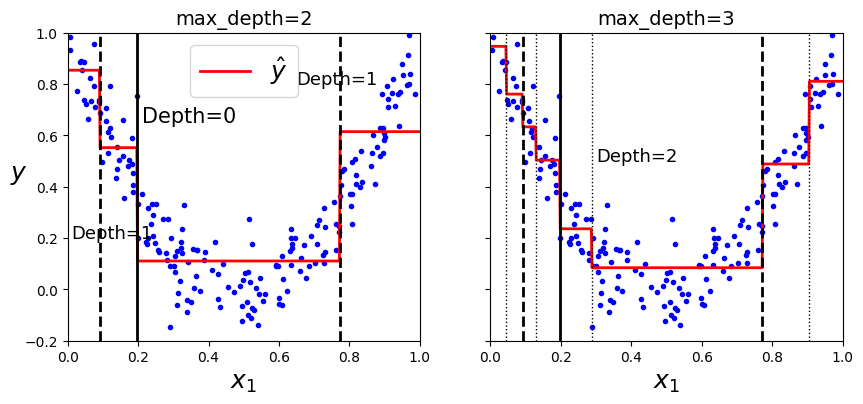

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# 1. 生成书中使用的带噪声二次数据集
np.random.seed(42)
m = 200
X = np.random.rand(m, 1)
y = 4 * (X - 0.5) ** 2
y = y + np.random.randn(m, 1) / 10

# 2. 训练两个不同深度的回归模型
tree_reg1 = DecisionTreeRegressor(random_state=42, max_depth=2)
tree_reg2 = DecisionTreeRegressor(random_state=42, max_depth=3)
tree_reg1.fit(X, y)
tree_reg2.fit(X, y)

# 3. 定义绘图函数来显示阶梯状预测边界
def plot_regression_predictions(tree_reg, X, y, axes=[0, 1, -0.2, 1], ylabel="$y$"):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$", fontsize=18)
    if ylabel:
        plt.ylabel(ylabel, fontsize=18, rotation=0)
    plt.plot(X, y, "b.") # 绘制原始数据点
    plt.plot(x1, y_pred, "r-", linewidth=2, label=r"$\hat{y}$") # 绘制预测阶梯

# 4. 绘图对比图 6-5
fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

# 左图：max_depth=2
plt.sca(axes[0])
plot_regression_predictions(tree_reg1, X, y)
for split, style in ((0.1973, "k-"), (0.0917, "k--"), (0.7718, "k--")):
    plt.plot([split, split], [-0.2, 1], style, linewidth=2)
plt.text(0.21, 0.65, "Depth=0", fontsize=15)
plt.text(0.01, 0.2, "Depth=1", fontsize=13)
plt.text(0.65, 0.8, "Depth=1", fontsize=13)
plt.legend(loc="upper center", fontsize=18)
plt.title("max_depth=2", fontsize=14)

# 右图：max_depth=3
plt.sca(axes[1])
plot_regression_predictions(tree_reg2, X, y, ylabel=None)
for split, style in ((0.1973, "k-"), (0.0917, "k--"), (0.7718, "k--")):
    plt.plot([split, split], [-0.2, 1], style, linewidth=2)
for split in (0.0458, 0.1298, 0.2873, 0.9040):
    plt.plot([split, split], [-0.2, 1], "k:", linewidth=1)
plt.text(0.3, 0.5, "Depth=2", fontsize=13)
plt.title("max_depth=3", fontsize=14)

plt.show()


回归树的预测结果呈“阶梯状”，深度越大，阶梯越细密，也就越容易过拟合。

---

### 代码要点解析

1. **分段常数预测**：红色的预测线 $\hat{y}$ ,它不是平滑的曲线，而是由一段段水平线组成的。每一个水平段对应回归树中的一个叶节点。
2. **垂直虚线**：代码中手动绘制的黑色虚线（如 `0.1973` 等）对应了树节点中的分裂阈值（即你在 `tree_reg.dot` 中看到的 `x1 <= 0.1973`）。
3. **深度对比**：
* **`max_depth=2`**：将数据分成了 4 个区间，预测较粗略。
* **`max_depth=3`**：将数据分成了 8 个区间，预测更贴合数据点，但也开始出现过拟合的苗头。

---


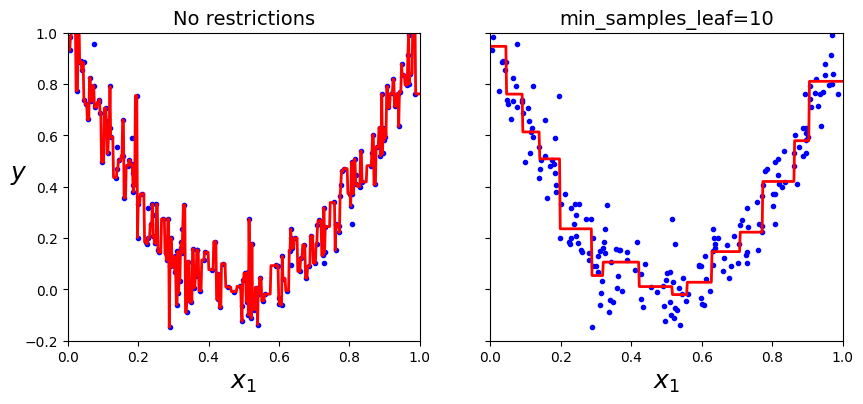

In [11]:
# 1. 训练两个模型：一个无约束，一个设置 min_samples_leaf=10
tree_reg1 = DecisionTreeRegressor(random_state=42) # 无约束
tree_reg2 = DecisionTreeRegressor(random_state=42, min_samples_leaf=10) # 限制叶节点最小样本数
tree_reg1.fit(X, y)
tree_reg2.fit(X, y)

# 2. 绘图对比图 6-6
fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

# 左图：无约束（容易过拟合）
plt.sca(axes[0])
plot_regression_predictions(tree_reg1, X, y)
plt.title("No restrictions", fontsize=14)

# 右图：min_samples_leaf=10（泛化更好）
plt.sca(axes[1])
plot_regression_predictions(tree_reg2, X, y, ylabel=None)
plt.title("min_samples_leaf=10", fontsize=14)

plt.show()


正则化能显著减少回归树的噪声，使预测曲线（阶梯）更加平滑，从而避免模型过度拟合训练数据中的随机波动。

---

### 结果深度分析

1. **左图：无约束（No restrictions）**：
* **表现**：预测线呈现出极其剧烈的上下波动，试图穿过每一个蓝色的数据点。
* **结论**：这在训练集上 MSE 可能很低，但在新数据上表现会很差，是典型的**过拟合**。


2. **右图：`min_samples_leaf=10**`：
* **表现**：预测阶梯变得宽大且平整，它捕捉的是数据整体的二次曲线趋势，而忽略了局部的随机噪声。
* **结论**：虽然在训练集上稍微增加了一些误差，但**泛化能力**（Generalization）得到了极大的提升。

---


## 不稳定性

虽然决策树易于理解且功能强大，但它们在实际应用中存在一些显著的局限性，总结为**不稳定性 (Instability)**。

理解这些局限性对于后续学习**集成学习（如随机森林）**至关重要，因为集成学习的核心目标之一就是通过组合多棵树来克服这些不稳定性。

---

### 1. 对正交性的敏感（数据旋转）

决策树的一个主要局限是它们偏好**正交的决策边界**（即所有分割线都垂直于坐标轴）。

* **问题描述**：如果数据集仅仅是简单地旋转了 **45°**，决策树就无法用一条斜线切开，而是必须通过大量的阶梯状分割来拟合。
* **后果**：这会导致模型变得极其复杂，且**泛化能力变差**。
* **解决方案**：在训练前使用 **PCA (主成分分析)** 来对数据进行旋转，使其在特征空间中更好地对齐。

---

### 2. 对数据变动的极度敏感

决策树对训练数据的**微小变化**非常敏感。

* **样本删除**：如果从鸢尾花数据集中仅仅删除一个样本（比如最宽的那朵变色鸢尾），重新训练出的决策树可能会长得完全不同。
* **随机性**：由于 Scikit-Learn 使用的优化算法在每个节点随机选择特征子集，即使在完全相同的数据上训练，如果没设置 `random_state`，也可能得到不同的模型。

---

### 3. 预测的局限性（阶梯状与外推）

正如在回归实验中看到的，决策树的预测是**分段常数**。

* **不平滑**：它无法产生平滑的预测曲线，只能给出“台阶”式的输出。
* **外推无力**：决策树无法对训练集范围之外的数据做出合理的预测。如果它在 $x \in [0, 1]$ 范围内训练，那么对于 $x=10$ 的预测值将永远等于它在训练集中能找到的最大/最小叶节点的值。

---

### 总结笔记

| 不稳定性类型 | 表现形式 | 缓解方法 |
| --- | --- | --- |
| **旋转敏感** | 数据旋转导致模型异常复杂 | 使用 PCA 预处理 |
| **数据敏感** | 少量样本变化导致树结构剧变 | 使用 **随机森林** 取平均值 |
| **预测受限** | 阶梯状输出，无法外推 | 结合其他线性模型或集成方法 |


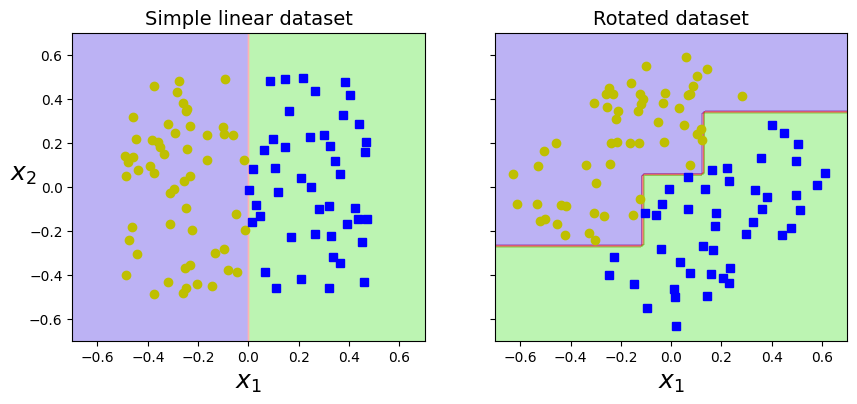

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# 1. 创建一个简单的线性可分数据集
np.random.seed(6)
Xs = np.random.rand(100, 2) - 0.5
ys = (Xs[:, 0] > 0).astype(np.float64) # 根据 x1 是否大于 0 分类

# 2. 将数据集旋转 45 度
angle = np.pi / 4 # 45度
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
Xsr = Xs.dot(rotation_matrix)

# 3. 训练两个决策树模型
tree_clf_s = DecisionTreeClassifier(random_state=42)
tree_clf_s.fit(Xs, ys)
tree_clf_sr = DecisionTreeClassifier(random_state=42)
tree_clf_sr.fit(Xsr, ys)

# 4. 定义绘图函数来显示决策边界
def plot_decision_boundary(clf, X, y, axes=[-0.7, 0.7, -0.7, 0.7]):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=plt.cm.brg)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)

# 5. 绘图对比
fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

# 左图：原始垂直数据（边界简单）
plt.sca(axes[0])
plot_decision_boundary(tree_clf_s, Xs, ys)
plt.title("Simple linear dataset", fontsize=14)

# 右图：旋转后的数据（边界变得极其复杂/阶梯状）
plt.sca(axes[1])
plot_decision_boundary(tree_clf_sr, Xsr, ys)
plt.title("Rotated dataset", fontsize=14)
plt.ylabel("")

plt.show()

我们需要展示决策树在面对线性可分但被旋转了角度的数据时，决策边界是如何从“简单”变得“极其复杂”的。

决策树的分类边界总是垂直或平行于坐标轴（正交），因此对于旋转后的斜向分布数据，它不得不产生大量的“阶梯状”分割。

---

### 结果深度解析

1. **左图：原始分布**：
* **表现**：因为类别区分线正好垂直于 $x_1$ 轴，决策树只需要“砍一刀”（一条直线）就能完美分类。


2. **右图：旋转 45° 后**：
* **表现**：虽然数据依然是线性可分的，但由于决策树无法画出斜线，它必须通过一系列细小的水平和垂直分割来逼近那条斜线，形成了明显的**阶梯状边界**。
* **后果**：这种边界对训练集的微小扰动非常敏感，泛化能力通常不如左侧的模型。

---

### 解决办法

针对这种“旋转敏感性”，实际开发中常用的对策是使用 **PCA（主成分分析）**。PCA 会自动将数据旋转到能够解释最大方差的方向，从而让决策树更容易找到简洁的分割方式。


最宽的 Versicolor 样本坐标: [[4.8 1.8]]


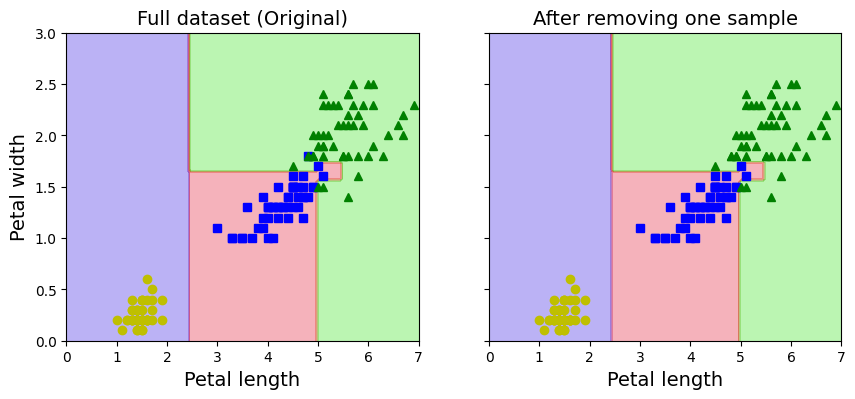

In [16]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt

# 1. 加载数据（仅使用花瓣长度和宽度）
iris = load_iris()
X = iris.data[:, 2:] # petal length, petal width
y = iris.target

# 2. 找到花瓣最宽的 Versicolor 样本（类别为 1）
# 在书中，这个点的坐标大约是 [4.8, 1.8]
widest_versicolor = X[(X[:, 1] == 1.8) & (y == 1)]
print(f"最宽的 Versicolor 样本坐标: {widest_versicolor}")

# 3. 创建排除该点后的新数据集
not_widest_versicolor = (X[:, 1] != 1.8) | (y != 1)
X_minus_one = X[not_widest_versicolor]
y_minus_one = y[not_widest_versicolor]

# 4. 训练两个模型
tree_clf_full = DecisionTreeClassifier(random_state=42) # 完整数据
tree_clf_full.fit(X, y)

tree_clf_minus = DecisionTreeClassifier(random_state=42) # 删除一个点后
tree_clf_minus.fit(X_minus_one, y_minus_one)

# 5. 绘图对比
def plot_decision_boundary(clf, X, y, axes=[0, 7, 0, 3]):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=plt.cm.brg)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
    plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris virginica")
    plt.axis(axes)
    plt.xlabel("Petal length", fontsize=14)
    plt.ylabel("Petal width", fontsize=14)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

# 左图：之前训练过的标准决策边界
plt.sca(axes[0])
plot_decision_boundary(tree_clf_full, X, y)
plt.title("Full dataset (Original)", fontsize=14)

# 右图：删除一个样本后的新边界
plt.sca(axes[1])
plot_decision_boundary(tree_clf_minus, X_minus_one, y_minus_one)
plt.title("After removing one sample", fontsize=14)
plt.ylabel("")

plt.show()

我们需要展示在同一个数据集（鸢尾花数据）上，仅仅**删除一个特定的样本点**，决策树的决策边界就会发生剧烈的变化。

这进一步证明了决策树作为一种非参数模型，其稳定性的脆弱——它太容易被个别“强力”的样本点牵着鼻子走。

---

### 结果深度解析

1. **左图：稳健的分割**：
* **表现**：模型在花瓣宽度 $1.75$ 处切了一刀，成功区分了绝大部分 Versicolor 和 Virginica。


2. **右图：剧烈的变动**：
* **表现**：仅仅删除了一个花瓣宽度为 $1.8$ 的蓝色点（Versicolor），重新训练出的决策树竟然完全放弃了原来的横向切割，改成了纵向切割。
* **结论**：这证明了决策树的训练过程具有很高的方差。即使是极小的数据变动，也可能导致整个分类逻辑的重组。

---

### 如何克服这种“敏感性”？

这种不稳定性正是下一章要学习的 **随机森林（Random Forests）** 存在的意义。

* 通过训练多棵不同的决策树并对它们的预测结果取平均值。
* 单棵树的极端偏差会被其他树“拉回来”，从而使模型变得非常稳健。
